<a href="https://colab.research.google.com/github/sanjanad2003/Underwater-Image-Enhancer/blob/main/hybrid.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install pytorch-ssim

  Preparing metadata (setup.py) ... done
  Created wheel for pytorch-ssim: filename=pytorch_ssim-0.1-py3-none-any.whl size=2006 sha256=e3ef88cb6118a7d3c74dbfad09adcacb2ed7d6b850bfe571f6150228fd44a8f6
  Stored in directory: /root/.cache/pip/wheels/58/68/a2/68a41e8268a076c128bbc3988d243187fa4681828e648bf1ca
Successfully built pytorch-ssim


In [ ]:
pip install torchmetrics


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 961.5/961.5 kB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 109.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 72.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 73.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 64.5 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstal

In [ ]:
!pip install gradio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 MB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.6/322.6 kB 33.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.2/95.2 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 118.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 kB 8.2 MB/s eta 0:00:00


In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
from tqdm import tqdm

import torch
import torch.nn as nn
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr
from PIL import Image
from torchvision import transforms
import timm
import torch.nn.functional as F


In [ ]:
class UIEBDataset(Dataset):
    def __init__(self, raw_dir, ref_dir, transform=None):
        self.raw_dir = raw_dir
        self.ref_dir = ref_dir
        self.raw_images = sorted(os.listdir(raw_dir))
        self.ref_images = sorted(os.listdir(ref_dir))
        self.transform = transform or transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))
        ])

    def __len__(self):
        return min(len(self.raw_images), len(self.ref_images))

    def __getitem__(self, idx):
        raw_path = os.path.join(self.raw_dir, self.raw_images[idx])
        ref_path = os.path.join(self.ref_dir, self.ref_images[idx])

        raw_img = Image.open(raw_path).convert('RGB')
        ref_img = Image.open(ref_path).convert('RGB')

        return self.transform(raw_img), self.transform(ref_img)

In [ ]:
import torch
import torch.nn as nn
import pytorch_ssim  # Ensure this is installed: pip install pytorch-ssim

class EnhancedHybridLoss(nn.Module):
    def __init__(self, alpha=0.5, beta=0.3, gamma=0.2, use_ssim=True):
        """
        :param alpha: Weight for L1 loss
        :param beta: Weight for L2 loss
        :param gamma: Weight for SSIM loss
        :param use_ssim: Use SSIM (True) or not (False)
        """
        super(EnhancedHybridLoss, self).__init__()
        self.alpha = alpha
        self.beta = beta
        self.gamma = gamma
        self.use_ssim = use_ssim

        self.l1 = nn.L1Loss()
        self.l2 = nn.MSELoss()
        self.ssim = pytorch_ssim.SSIM(window_size=11) if use_ssim else None

    def forward(self, output, target):
        l1_loss = self.l1(output, target)
        l2_loss = self.l2(output, target)
        ssim_loss = 1 - self.ssim(output, target) if self.use_ssim else 0.0

        total_loss = (
            self.alpha * l1_loss +
            self.beta * l2_loss +
            self.gamma * ssim_loss
        )
        return total_loss

# Example usage
criterion = EnhancedHybridLoss(alpha=0.5, beta=0.3, gamma=0.2, use_ssim=True)


In [ ]:
class UNetGenerator(nn.Module):
    def __init__(self, input_nc=3, output_nc=3):
        super(UNetGenerator, self).__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(input_nc, 64, 4, 2, 1),
            nn.LeakyReLU(0.2, True),
            nn.Conv2d(64, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, True),
            nn.Conv2d(128, 256, 4, 2, 1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, True),
        )

        self.middle = nn.Sequential(
            nn.Conv2d(256, 512, 4, 2, 1),
            nn.ReLU(True),
            nn.ConvTranspose2d(512, 256, 4, 2, 1),
            nn.ReLU(True),
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(512, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.ConvTranspose2d(64, output_nc, 4, 2, 1),
            nn.Tanh()
        )

    def forward(self, x):
        enc_out = self.encoder(x)
        mid = self.middle(enc_out)
        dec_input = torch.cat([mid, enc_out], dim=1)
        output = self.decoder(dec_input)
        return output


In [ ]:
class SwinFeatureExtractor(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = timm.create_model('swin_base_patch4_window7_224', pretrained=True, features_only=True)
        self.pool = nn.AdaptiveAvgPool2d((8, 8))

    def forward(self, x):
        feat = self.backbone(x)[-1]
        feat = self.pool(feat)
        return feat

In [ ]:
class HybridEnhancer(nn.Module):
    def __init__(self):
        super(HybridEnhancer, self).__init__()

        self.funie = UNetGenerator()
        self.swin = timm.create_model('swin_tiny_patch4_window7_224', pretrained=True, features_only=True)

        self.fusion = nn.Sequential(
            nn.Conv2d(771, 64, kernel_size=1),
            nn.ReLU(),
            nn.Conv2d(64, 3, kernel_size=3, padding=1),
            nn.Tanh()
        )

    def forward(self, x):
        funie_out = self.funie(x)
        swin_feat = self.swin(x)[3]  # [B, C, H, W]
        swin_feat = swin_feat.permute(0, 3, 1, 2)
        swin_feat_upsampled = nn.functional.interpolate(swin_feat, size=funie_out.shape[2:], mode='bilinear', align_corners=False)
        fused = torch.cat([funie_out, swin_feat_upsampled], dim=1)
        out = self.fusion(fused)
        return out

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = HybridEnhancer().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=2e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = HybridEnhancer().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=2e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)

# 👇 Pass device to HybridLoss
loss_fn = HybridLoss(alpha=0.8, device=device)

train_dataset = UIEBDataset('/content/drive/MyDrive/dataset/train/raw', '/content/drive/MyDrive/dataset/train/ref')
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)

for epoch in range(150):
    model.train()
    total_loss = 0
    for input_img, target_img in tqdm(train_loader):
        input_img, target_img = input_img.to(device), target_img.to(device)
        optimizer.zero_grad()
        output = model(input_img)
        loss = loss_fn(output, target_img)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    scheduler.step()
    print(f"Epoch {epoch+1}, Loss: {total_loss / len(train_loader):.4f}")

    model.eval()

torch.save(model.state_dict(), '/content/drive/MyDrive/hybrid_enhancer1.pth')


100%|██████████| 75/75 [02:52<00:00,  2.29s/it]


Epoch 1, Loss: 0.2372


100%|██████████| 75/75 [00:55<00:00,  1.35it/s]


Epoch 2, Loss: 0.1583


100%|██████████| 75/75 [00:55<00:00,  1.35it/s]


...

Epoch 148, Loss: 0.0103


100%|██████████| 75/75 [00:55<00:00,  1.35it/s]


Epoch 149, Loss: 0.0101


100%|██████████| 75/75 [00:55<00:00,  1.34it/s]


Epoch 150, Loss: 0.0101


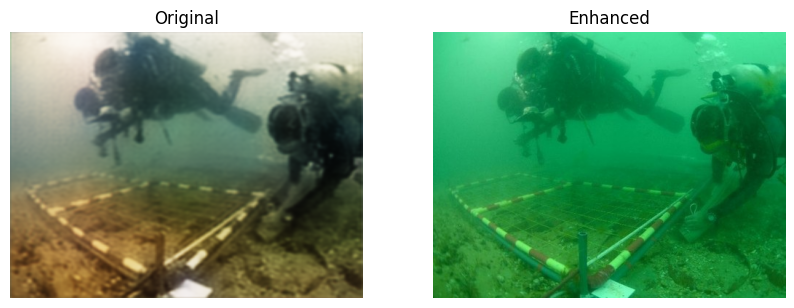

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

# Load the trained model
model = HybridEnhancer().to(device)
model.load_state_dict(torch.load('/content/drive/MyDrive/hybrid_enhancer1.pth', map_location=device))
model.eval()

# Manually set path to input image
input_image_path = '/content/drive/MyDrive/dataset/test/raw/105_img_.png'  # <- change this path

# Load and preprocess the image
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

image = Image.open(input_image_path).convert('RGB')
input_tensor = transform(image).unsqueeze(0).to(device)

# Enhance image
with torch.no_grad():
    enhanced_tensor = model(input_tensor).squeeze(0).cpu()

    original_size = image.size  # (width, height)
enhanced_tensor_resized = F.interpolate(enhanced_tensor.unsqueeze(0), size=(original_size[1], original_size[0]), mode='bilinear', align_corners=False).squeeze(0)

# Unnormalize and convert back to image for visualization
def unnormalize(tensor):
    tensor = tensor * 0.5 + 0.5  # Undo normalization
    tensor = torch.clamp(tensor, 0, 1)
    return tensor.permute(1, 2, 0).numpy()

enhanced_img = unnormalize(enhanced_tensor_resized)
#enhanced_img = post_process_image(enhanced_img)  # Add this line
filtered_img = cv2.bilateralFilter(enhanced_img, d=9, sigmaColor=75, sigmaSpace=75) #new edit

def post_process_image(enhanced_img):
    # Convert to uint8 image
    img = (enhanced_img * 255).astype(np.uint8)

    # Step 1: Reduce grid artifacts (light blur)
    img = cv2.medianBlur(img, 1)  # Better for reducing grid artifacts

    # Step 2: Convert to YUV and enhance brightness/contrast
    yuv = cv2.cvtColor(img, cv2.COLOR_RGB2YUV)
    yuv[:,:,0] = cv2.equalizeHist(yuv[:,:,0])  # Histogram equalization on Y channel
    img = cv2.cvtColor(yuv, cv2.COLOR_YUV2RGB)

    # Step 3: Sharpening (Unsharp masking without over-darkening)
    gaussian = cv2.GaussianBlur(img, (3, 3), 0)
    sharpened = cv2.addWeighted(img, 1.3, gaussian, -0.8, 0)

    # Convert back to float [0,1] for matplotlib
    return sharpened.astype(np.float32) / 255.0

"""lab = cv2.cvtColor(filtered_img, cv2.COLOR_RGB2LAB)
l, a, b = cv2.split(lab)
clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
cl = clahe.apply(l)
limg = cv2.merge((cl, a, b))
final_output = cv2.cvtColor(limg, cv2.COLOR_LAB2RGB)"""


# Show original and enhanced side-by-side
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(enhanced_img)
plt.title('Original')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(image)
plt.title('Enhanced') #
plt.axis('off')


plt.show()


In [ ]:
from skimage.color import rgb2lab
from skimage.metrics import mean_squared_error
from scipy.ndimage import sobel
import numpy as np

# Testing
test_dataset = UIEBDataset('/content/drive/MyDrive/dataset/test/raw',
                           '/content/drive/MyDrive/dataset/test/ref')
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

model.eval()
psnr_total, ssim_total, mse_total, rmse_total = 0, 0, 0, 0
color_acc_total, noise_red_total, edge_pres_total = 0, 0, 0

def edge_preservation_score(ref, enhanced):
    # Convert to grayscale
    ref_gray = np.mean(ref, axis=2)
    enh_gray = np.mean(enhanced, axis=2)

    # Compute Sobel edges
    edge_ref = np.hypot(sobel(ref_gray, axis=0), sobel(ref_gray, axis=1))
    edge_enh = np.hypot(sobel(enh_gray, axis=0), sobel(enh_gray, axis=1))

    # Compute similarity
    return 1 - np.mean(np.abs(edge_ref - edge_enh)) / np.max(edge_ref)

def color_accuracy(ref, enhanced):
    ref_lab = rgb2lab(ref)
    enh_lab = rgb2lab(enhanced)
    deltaE = np.linalg.norm(ref_lab - enh_lab, axis=2)
    return 1 - np.mean(deltaE) / 100  # Normalize to range [0,1]

def noise_reduction(raw, enhanced):
    noise_before = np.var(raw - enhanced)
    return 1 - noise_before  # Inverted so higher = better

with torch.no_grad():
    for raw_img, ref_img in tqdm(test_loader):
        raw_img, ref_img = raw_img.to(device), ref_img.to(device)
        enhanced = model(raw_img)

        raw_np = raw_img.squeeze().cpu().clamp(0, 1).numpy().transpose(1, 2, 0)
        enhanced_np = enhanced.squeeze().cpu().clamp(0, 1).numpy().transpose(1, 2, 0)
        ref_np = ref_img.squeeze().cpu().clamp(0, 1).numpy().transpose(1, 2, 0)

        # PSNR & SSIM
        psnr_total += psnr(ref_np, enhanced_np, data_range=1)
        ssim_total += ssim(ref_np, enhanced_np, data_range=1, channel_axis=2)

        # MSE & RMSE
        mse_val = mean_squared_error(ref_np, enhanced_np)
        mse_total += mse_val
        rmse_total += np.sqrt(mse_val)

        # Color Accuracy
        color_acc_total += color_accuracy(ref_np, enhanced_np)

        # Noise Reduction Estimation
        noise_red_total += noise_reduction(raw_np, enhanced_np)

        # Edge Preservation
        edge_pres_total += edge_preservation_score(ref_np, enhanced_np)

# Number of samples
n = len(test_loader)
print("\n--- Evaluation Metrics ---")
print(f"Average PSNR: {psnr_total / n:.2f}")
print(f"Average SSIM: {ssim_total / n:.4f}")
print(f"Average MSE: {mse_total / n:.6f}")
print(f"Average RMSE: {rmse_total / n:.6f}")
print(f"Average Color Accuracy: {color_acc_total / n:.4f}")
print(f"Average Noise Reduction Score: {noise_red_total / n:.4f}")
print(f"Average Edge Preservation Score: {edge_pres_total / n:.4f}")


In [ ]:
import gradio as gr
from PIL import Image
import torch.nn.functional as F
import torch
from torchvision import transforms

# Ensure your model is already loaded and `model.eval()` has been called
# Ensure `device` is defined and set to 'cuda' or 'cpu'

# Example device and model loading (you should replace this with your actual model and device setup)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# model = your_pretrained_model.to(device)

# Use the same transform and unnormalize functions from earlier
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

def unnormalize(tensor):
    tensor = tensor * 0.5 + 0.5
    tensor = torch.clamp(tensor, 0, 1)
    return tensor.permute(1, 2, 0).cpu().numpy()

def enhance_gradio(img):
    input_tensor = transform(img).unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(input_tensor).squeeze(0)
        output_resized = F.interpolate(output.unsqueeze(0), size=img.size[::-1], mode='bilinear', align_corners=False).squeeze(0)
        enhanced_img = unnormalize(output_resized)
        enhanced_img = (enhanced_img * 255).astype("uint8")
        return enhanced_img, img  # Return both enhanced and input image

# Create Gradio interface
gr.Interface(
    fn=enhance_gradio,
    inputs=gr.Image(type="pil", label="Upload Underwater Image", visible=True),  # Input for image upload
    outputs=[gr.Image(type="pil", label="Enhanced Image"), gr.Image(type="pil", label="Input Image")],  # Show both input and output images side by side
    title="Underwater Image Enhancer - Hybrid Model",
    description="Upload a raw underwater image to get an enhanced result using your trained model.",
    live=False  # Ensures that the image only updates once the submit button is clicked
).launch(debug=True)


It looks like you are running Gradio on a hosted a Jupyter notebook. For the Gradio app to work, sharing must be enabled. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://26bc650b34947f1c6c.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://26bc650b34947f1c6c.gradio.live
